In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/ml

# 2. Ask Python to check what folder it is currently in (just to prove it worked!)
!pwd
!python3 setup.py
!pip install -e .
%cd /content/drive/MyDrive/ml/sasrec
!pwd

/content/drive/MyDrive/ml
/content/drive/MyDrive/ml
usage: setup.py [global_opts] cmd1 [cmd1_opts] [cmd2 [cmd2_opts] ...]
   or: setup.py --help [cmd1 cmd2 ...]
   or: setup.py --help-commands
   or: setup.py cmd --help

error: no commands supplied
Obtaining file:///content/drive/MyDrive/ml
  Preparing metadata (setup.py) ... done
  Running setup.py develop for ProjectMl
/content/drive/MyDrive/ml/sasrec
/content/drive/MyDrive/ml/sasrec


In [8]:
!python3 train.py --outdir="/content" --seeds 5

Total processed movie items in catalog: 3707

--- Running Training Execution with Seed 5 ---
Training on cuda
Found checkpoint at /content/sasrec_checkpoint_seed_5.pth. Resuming training...
Successfully resumed. Starting from Epoch 3
Epoch [3/100] | Train Loss: 7.6258 | Val HR@10: 0.0495 | Val NDCG@10: 0.0233
Epoch [4/100] | Train Loss: 7.5700 | Val HR@10: 0.0621 | Val NDCG@10: 0.0300
Epoch [5/100] | Train Loss: 7.4050 | Val HR@10: 0.0982 | Val NDCG@10: 0.0492
Epoch [6/100] | Train Loss: 7.0044 | Val HR@10: 0.1548 | Val NDCG@10: 0.0814
Epoch [7/100] | Train Loss: 6.5606 | Val HR@10: 0.2263 | Val NDCG@10: 0.1233
Epoch [8/100] | Train Loss: 6.2645 | Val HR@10: 0.2735 | Val NDCG@10: 0.1494
Epoch [9/100] | Train Loss: 6.0750 | Val HR@10: 0.3174 | Val NDCG@10: 0.1755
Epoch [10/100] | Train Loss: 5.9381 | Val HR@10: 0.3455 | Val NDCG@10: 0.1954
Epoch [11/100] | Train Loss: 5.8369 | Val HR@10: 0.3646 | Val NDCG@10: 0.2068
Epoch [12/100] | Train Loss: 5.7693 | Val HR@10: 0.3806 | Val NDCG@10: 


Plot successfully saved to: /content/models_comparison_plot.png


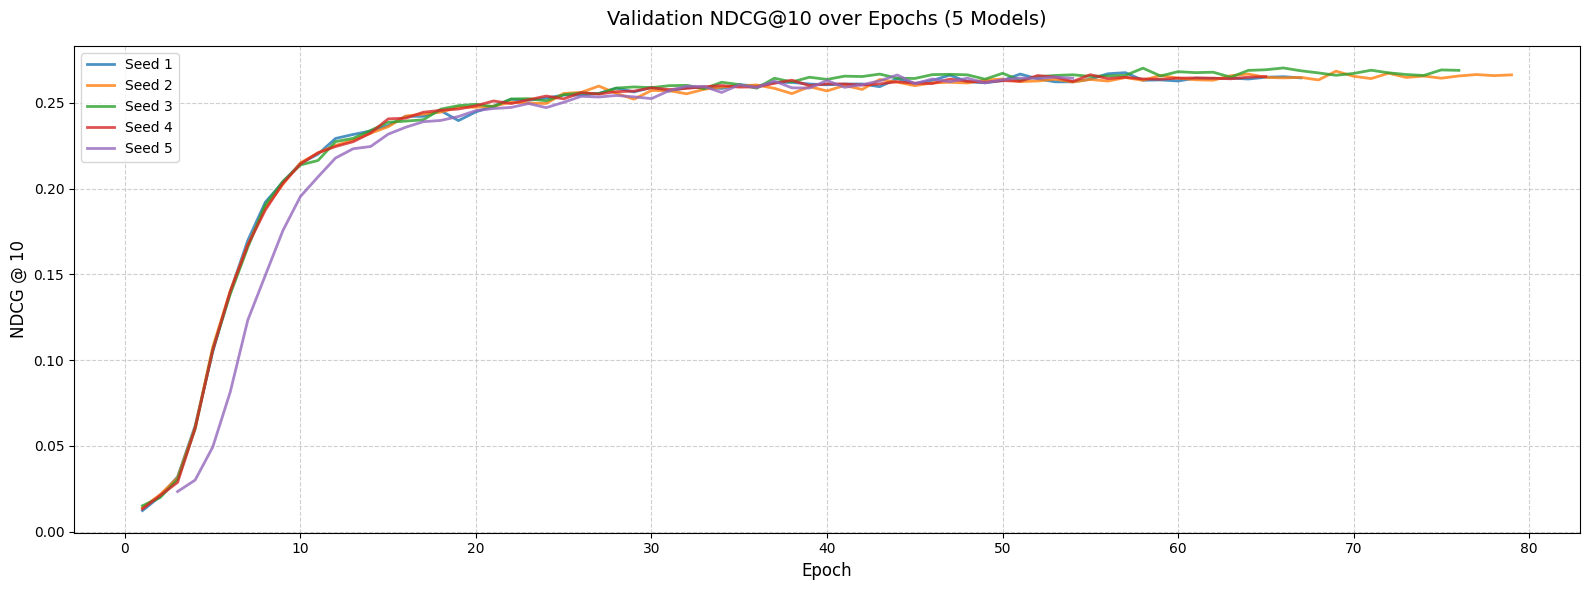

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics(out_dir='outputs', seeds=[1, 2, 3, 4, 5]):
    # Create a figure with 2 subplots (side-by-side)
    fig, (ax2) = plt.subplots(1, 1, figsize=(16, 6))

    # Define some distinct colors for the 5 lines
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    found_any = False

    for i, seed in enumerate(seeds):
        csv_path = os.path.join(out_dir, f"metrics_log_seed_{seed}.csv")

        if os.path.exists(csv_path):
            found_any = True
            # Read the CSV file
            df = pd.read_csv(csv_path)

            # We add +1 to the epoch so the X-axis starts at 1 instead of 0
            epochs = df['epoch'] + 1

            # 1. Plot Training Loss on the first graph
            #ax1.plot(epochs, df['train_loss'], label=f'Seed {seed}',
                     #color=colors[i % len(colors)], linewidth=2, alpha=0.8)

            # 2. Plot NDCG on the second graph
            ax2.plot(epochs, df['ndcg'], label=f'Seed {seed}',
                     color=colors[i % len(colors)], linewidth=2, alpha=0.8)
        else:
            print(f"Warning: Could not find {csv_path}")

    if not found_any:
        print(f"\nError: No CSV files found in the '{out_dir}' directory.")
        return

    # --- Formatting Graph 1: Training Loss ---
    #ax1.set_title('Training Loss over Epochs (5 Models)', fontsize=14, pad=15)
    #ax1.set_xlabel('Epoch', fontsize=12)
    #ax1.set_ylabel('Loss (Cross Entropy)', fontsize=12)
    #ax1.grid(True, linestyle='--', alpha=0.6)
    #ax1.legend(fontsize=10)

    # --- Formatting Graph 2: Validation NDCG@10 ---
    ax2.set_title('Validation NDCG@10 over Epochs (5 Models)', fontsize=14, pad=15)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('NDCG @ 10', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(fontsize=10)

    # Automatically adjust layout so labels don't overlap
    plt.tight_layout()

    # Save a high-resolution image to the output folder
    save_path = os.path.join(out_dir, 'models_comparison_plot.png')
    plt.savefig(save_path, dpi=300)
    print(f"\nPlot successfully saved to: {save_path}")

    # Show the plot on screen
    plt.show()

SEEDS_TO_PLOT = [1,2,3,4,5]
OUTPUT_DIRECTORY = '/content'

plot_metrics(out_dir=OUTPUT_DIRECTORY, seeds=SEEDS_TO_PLOT)